In [32]:
import pandas as pd
data = pd.read_csv('Static-Binary classification dataset.csv')

In [33]:
data['Class'].value_counts()

Class
B    1800
M    1747
Name: count, dtype: int64

In [34]:
null_counts = data.isnull().sum()

# Display the null counts for each column
print("Null values in each column:\n", null_counts)

# Total number of null values in the entire dataset
total_nulls = data.isnull().sum().sum()
print("\nTotal number of null values in the dataset:", total_nulls)

Null values in each column:
  android.intent.action.ACTION_POWER_CONNECTED             0
android.permission.ACCESS_BLUETOOTH_SHARE                 0
android.permission.ACCESS_CACHE_FILESYSTEM                0
android.Intent.action.Battery_LOW                         0
android.permission.ACCESS_CONTENT_PROVIDERS_EXTERNALLY    0
                                                         ..
mount                                                     0
/system/bin                                               0
/system/app                                               0
chown                                                     0
Class                                                     0
Length: 353, dtype: int64

Total number of null values in the dataset: 0


In [35]:
X = data.drop('Class', axis=1)
y = data['Class'].map({'M': 1, 'B': 0}) # لي بنقسمهم ل x and y 

In [36]:
print("Number of features:", X.shape[1])

Number of features: 352


In [37]:
from sklearn.feature_selection import VarianceThreshold

# إنشاء كائن VarianceThreshold بعتبة 0.01
selector = VarianceThreshold(threshold=0.01)

# تطبيق العتبة على البيانات لإزالة الميزات ذات التباين المنخفض
X_selected = selector.fit_transform(X)

# الحصول على أسماء الميزات التي تم الاحتفاظ بها
selected_features = X.columns[selector.get_support()].tolist()

# طباعة عدد الميزات المختارة وأسمائها
print("Number of selected features:", X_selected.shape[1])
print("Selected features:", selected_features)

Number of selected features: 83
Selected features: ['android.permission.ACCESS_LOCATION_EXTRA_COMMANDS', 'android.permission.ACCESS_NETWORK_STATE', 'android.permission.ACCESS_NOTIFICATION_POLICY', 'android.permission.ACCESS_WIFI_STATE', 'android.permission.AUTHENTICATE_ACCOUNTS', 'android.permission.BATTERY_STATS', 'android.permission.BIND_ACCESSIBILITY_SERVICE', 'android.permission.BIND_APPWIDGET', 'android.permission.BIND_DEVICE_ADMIN', 'android.permission.BIND_JOB_SERVICE', 'android.permission.BIND_NOTIFICATION_LISTENER_SERVICE', 'android.permission.BIND_QUICK_SETTINGS_TILE', 'android.permission.BIND_REMOTEVIEWS', ' android.permission.BIND_WALLPAPER', ' android.permission.BLUETOOTH', ' android.permission.BLUETOOTH_ADMIN', ' android.permission.BROADCAST_STICKY', 'android.permission.CHANGE_CONFIGURATION', 'android.permission.CHANGE_NETWORK_STATE', 'android.permission.CHANGE_WIFI_MULTICAST_STATE', 'android.permission.CHANGE_WIFI_STATE', 'android.permission.CLEAR_APP_CACHE', 'android.pe

In [38]:
variances = X.var()   #لي استخدمنا دي و فادتنا ف اي ف تحديد ال threshold
print("Variance summary:\n", variances.describe())

Variance summary:
 count    352.000000
mean       0.025805
std        0.062717
min        0.000000
25%        0.000000
50%        0.000282
75%        0.007834
max        0.250058
dtype: float64


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_selected, X_test_selected = train_test_split(X_selected, test_size=0.2, random_state=42)

# تدريب على البيانات الأصلية
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Original Data (352 features):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

# تدريب على البيانات المختارة
rf.fit(X_train_selected, y_train)
y_pred_selected = rf.predict(X_test_selected)
print("\nSelected Data (83 features):")
print("Accuracy:", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected))
print("Recall:", recall_score(y_test, y_pred_selected))
print("F1-Score:", f1_score(y_test, y_pred_selected))

Original Data (352 features):
Accuracy: 0.9816901408450704
Precision: 0.9781420765027322
Recall: 0.9862258953168044
F1-Score: 0.9821673525377229

Selected Data (83 features):
Accuracy: 0.9788732394366197
Precision: 0.978021978021978
Recall: 0.9807162534435262
F1-Score: 0.9793672627235214


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import VarianceThreshold
import pandas as pd


# تحميل البيانات
#data = pd.read_csv('Static-Binary classification dataset.csv')
#X = data.drop('Class', axis=1)
#y = data['Class'].map({'M': 1, 'B': 0})  # تحويل التسميات إلى 1 (Malware) و0 (Benign)

# تطبيق VarianceThreshold مع threshold=0.01

# تدريب نموذج Random Forest على البيانات المختارة (83 ميزة)
rf.fit(X_train_selected, y_train)
y_pred_selected = rf.predict(X_test_selected)

# طباعة Confusion Matrix للبيانات المختارة (83 ميزة)
cm = confusion_matrix(y_test, y_pred_selected)

# طباعة القيم بشكل واضح
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")


True Negatives (TN): 339
False Positives (FP): 8
False Negatives (FN): 7
True Positives (TP): 356


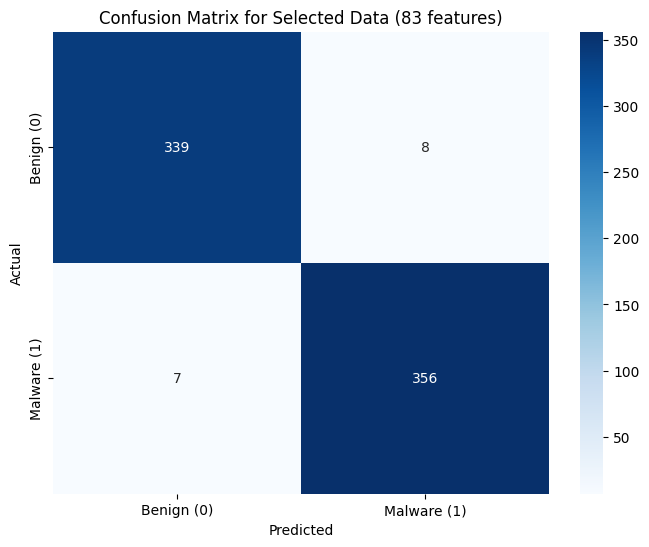

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
 
 # رسم Confusion Matrix كمخطط باستخدام seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malware (1)'], 
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title('Confusion Matrix for Selected Data (83 features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

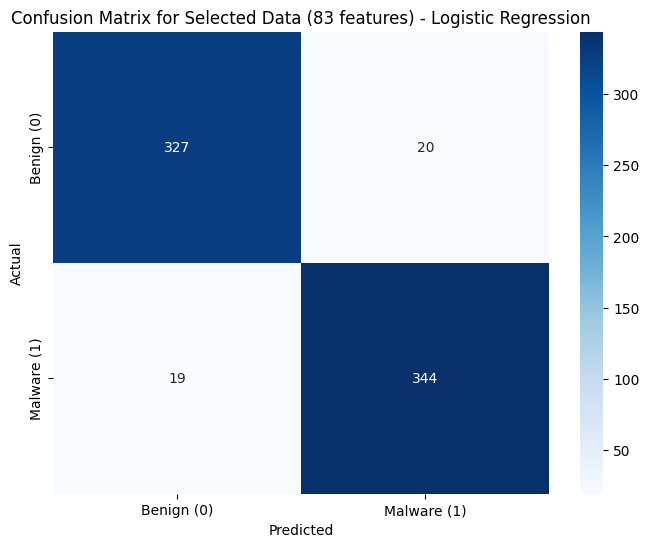


True Negatives (TN): 327
False Positives (FP): 20
False Negatives (FN): 19
True Positives (TP): 344


In [42]:
from sklearn.linear_model import LogisticRegression

# تدريب نموذج Logistic Regression على البيانات المختارة (83 ميزة)
lr = LogisticRegression(random_state=42, max_iter=1000)  # max_iter لضمان التقارب
lr.fit(X_train_selected, y_train)
y_pred_selected = lr.predict(X_test_selected)

# حساب Confusion Matrix
cm = confusion_matrix(y_test, y_pred_selected)

# رسم Confusion Matrix كمخطط باستخدام seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malware (1)'], 
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title('Confusion Matrix for Selected Data (83 features) - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# طباعة القيم بشكل نصي
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")

In [43]:
lr.fit(X_train_selected, y_train)
y_pred_selected = lr.predict(X_test_selected)
print("\nFor Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected))
print("Recall:", recall_score(y_test, y_pred_selected))
print("F1-Score:", f1_score(y_test, y_pred_selected))


For Logistic Regression
Accuracy: 0.9450704225352112
Precision: 0.945054945054945
Recall: 0.9476584022038568
F1-Score: 0.9463548830811555


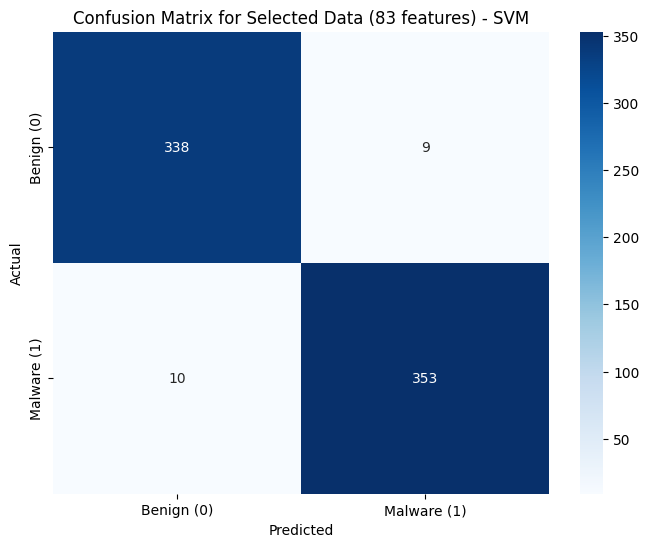


True Negatives (TN): 338
False Positives (FP): 9
False Negatives (FN): 10
True Positives (TP): 353


In [44]:
from sklearn.svm import SVC

# تدريب نموذج SVM على البيانات المختارة (83 ميزة)
svm = SVC(random_state=42)  # استخدام Kernel افتراضي (RBF)
svm.fit(X_train_selected, y_train)
y_pred_selected = svm.predict(X_test_selected)


# حساب Confusion Matrix
cm = confusion_matrix(y_test, y_pred_selected)

# رسم Confusion Matrix كمخطط باستخدام seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malware (1)'], 
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title('Confusion Matrix for Selected Data (83 features) - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# طباعة القيم بشكل نصي
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")

In [45]:
svm.fit(X_train_selected, y_train)
y_pred_selected = svm.predict(X_test_selected)
print("Support Vector Machine (SVM):")
print("Accuracy:", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected))
print("Recall:", recall_score(y_test, y_pred_selected))
print("F1-Score:", f1_score(y_test, y_pred_selected))

Support Vector Machine (SVM):
Accuracy: 0.9732394366197183
Precision: 0.9751381215469613
Recall: 0.9724517906336089
F1-Score: 0.9737931034482759


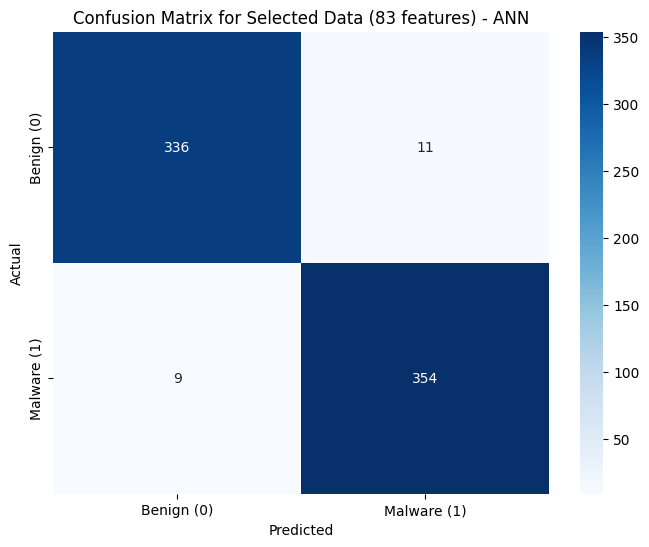


True Negatives (TN): 336
False Positives (FP): 11
False Negatives (FN): 9
True Positives (TP): 354


In [46]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler


# معالجة البيانات (Normalization) لأن ANN يعمل بشكل أفضل مع بيانات موحدة
scaler = StandardScaler()
X_train_selected = scaler.fit_transform(X_train_selected)
X_test_selected = scaler.transform(X_test_selected)

# تدريب نموذج ANN (MLPClassifier) على البيانات المختارة (83 ميزة)
ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)  # طبقة مخفية واحدة مع 100 عصبون
ann.fit(X_train_selected, y_train)
y_pred_selected = ann.predict(X_test_selected)


# حساب Confusion Matrix
cm = confusion_matrix(y_test, y_pred_selected)

# رسم Confusion Matrix كمخطط باستخدام seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malware (1)'], 
            yticklabels=['Benign (0)', 'Malware (1)'])
plt.title('Confusion Matrix for Selected Data (83 features) - ANN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# طباعة القيم بشكل نصي
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP): {TP}")

In [47]:
ann.fit(X_train_selected, y_train)
y_pred_selected = ann.predict(X_test_selected)
print("Artificial Neural Network (ANN)")
print("Accuracy:", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected))
print("Recall:", recall_score(y_test, y_pred_selected))
print("F1-Score:", f1_score(y_test, y_pred_selected))

Artificial Neural Network (ANN)
Accuracy: 0.971830985915493
Precision: 0.9698630136986301
Recall: 0.9752066115702479
F1-Score: 0.9725274725274725
